# Visualizing the GC2D HDF5 potential

This notebook loads the project HDF5 potential through the public API and visualizes its mean, dynamic, and total components, its electric field, and its evolution over ten normalized temporal periods.

The HDF5 loader uses unit-box spatial normalization in this notebook, so the complete periodic x and y domains both have length $1$. The characteristic temporal period is also mapped to $1$.

## Configuration

Run Jupyter from the repository environment. `MODE_SELECTION = (0, 1)` loads the mean field and the dominant positive-frequency mode; use `None` to load every available positive-frequency mode. `SPATIAL_NORMALIZATION = "unit_box"` maps both complete spatial periods to 1. The default temporal grid uses 10 integration steps and 10 saved steps per normalized cycle; animations display one saved step per frame at 5 frames per second.

In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from diagnostics.paths import find_project_root
from potential import load_gc2d_h5_potential
from visualization import animate_potential, display_animation, plot_potential

PROJECT_ROOT = find_project_root(Path.cwd())
DATA_PATH = PROJECT_ROOT / "data/potential/V1/PHI_2.h5"
MAGNETIC_FIELD = 1.5
CHARACTERISTIC_LENGTH = 0.06
MODE_SELECTION = (0, 1)
SPATIAL_NORMALIZATION = "unit_box"
INTERPOLATION_ORDER = 3
SNAPSHOT_TIME = 0.0
FINAL_TIME = 10.0
INTEGRATION_STEPS_PER_CYCLE = 10
SAVED_STEPS_PER_CYCLE = 10
ANIMATION_FPS = 5
INTEGRATION_TIME_STEP = 1.0 / INTEGRATION_STEPS_PER_CYCLE
SAVED_TIME_STEP = 1.0 / SAVED_STEPS_PER_CYCLE
SAVED_SAMPLE_COUNT = int(round(FINAL_TIME / SAVED_TIME_STEP)) + 1
ANIMATION_FRAMES = SAVED_SAMPLE_COUNT - 1
ANIMATION_INTERVAL_MS = int(round(1000.0 / ANIMATION_FPS))

if not DATA_PATH.is_file():
    raise FileNotFoundError(f"HDF5 potential not found: {DATA_PATH}")

## Load the potential

In [2]:
potential = load_gc2d_h5_potential(
    DATA_PATH,
    B=MAGNETIC_FIELD,
    characteristic_length=CHARACTERISTIC_LENGTH,
    indx=MODE_SELECTION,
    interpolation_order=INTERPOLATION_ORDER,
    spatial_normalization=SPATIAL_NORMALIZATION,
)

metadata = potential.metadata
if metadata is None:
    raise RuntimeError("The HDF5 loader did not attach provenance metadata.")
if SPATIAL_NORMALIZATION == "unit_box":
    np.testing.assert_allclose(potential.grid.period, 1.0)

frequencies = np.asarray(potential.frequencies, dtype=float)
periods = 1.0 / frequencies
fundamental_period = float(periods[0])
snapshot_time = SNAPSHOT_TIME

print(f"Source: {metadata.source_path}")
print(f"Array shape: {potential.grid.shape}")
print(f"Source x bounds: [{metadata.source_x[0]:.9g}, {metadata.source_x[-1]:.9g}]")
print(f"Source y bounds: [{metadata.source_y[0]:.9g}, {metadata.source_y[-1]:.9g}]")
print(f"Runtime x samples: [{potential.grid.x[0]:.9g}, {potential.grid.x[-1]:.9g}]")
print(f"Runtime y samples: [{potential.grid.y[0]:.9g}, {potential.grid.y[-1]:.9g}]")
print(f"Runtime x and y period: {potential.grid.period:.9g}")
print(f"Spatial normalization: {metadata.spatial_normalization}")
print(f"Characteristic length: {metadata.characteristic_length:.9g}")
print(f"Characteristic angular frequency: {metadata.characteristic_frequency:.9g}")
print(f"Characteristic period: {metadata.characteristic_period:.9g}")
print(f"Selected source field indices: {metadata.source_field_indices.tolist()}")
print(f"Selected source angular frequencies: {metadata.source_frequencies.tolist()}")
print(f"Normalized cycle frequencies: {frequencies.tolist()}")
print(f"Normalized temporal periods: {periods.tolist()}")
print(f"Snapshot time: {snapshot_time:.9g}")
print(f"Final normalized time: {FINAL_TIME:.9g}")
print(f"Cycles covered: {FINAL_TIME / fundamental_period:.9g}")
print(f"Integration steps per cycle: {INTEGRATION_STEPS_PER_CYCLE}")
print(f"Saved steps per cycle: {SAVED_STEPS_PER_CYCLE}")
print(f"Integration time step: {INTEGRATION_TIME_STEP:.9g}")
print(f"Saved time step: {SAVED_TIME_STEP:.9g}")
print(f"Saved samples including both endpoints: {SAVED_SAMPLE_COUNT}")
print(f"Animation: {ANIMATION_FRAMES} frames at {ANIMATION_FPS} fps")

Source: /home/juan/Proyectos/GC2D_intranet/data/potential/V1/PHI_2.h5
Array shape: (256, 256)
Source x bounds: [0.000703125, 0.18]
Source y bounds: [0.0003515625, 0.179648437]
Runtime x samples: [0, 0.99609375]
Runtime y samples: [0, 0.99609375]
Runtime x and y period: 1
Spatial normalization: unit_box
Characteristic length: 0.06
Characteristic angular frequency: 2404.10668
Characteristic period: 0.00261352184
Selected source field indices: [15]
Selected source angular frequencies: [2404.106675108847]
Normalized cycle frequencies: [1.0]
Normalized temporal periods: [1.0]
Snapshot time: 0
Final normalized time: 10
Cycles covered: 10
Integration steps per cycle: 10
Saved steps per cycle: 10
Integration time step: 0.1
Saved time step: 0.1
Saved samples including both endpoints: 101
Animation: 100 frames at 5 fps


For the supplied `PHI_2.h5` file, the loader retains one positive frequency. Therefore the full potential has the exact normalized temporal period $\hat T=1/\hat f=1$. The stationary mean field does not change this period.

## Mean, dynamic, and total potential

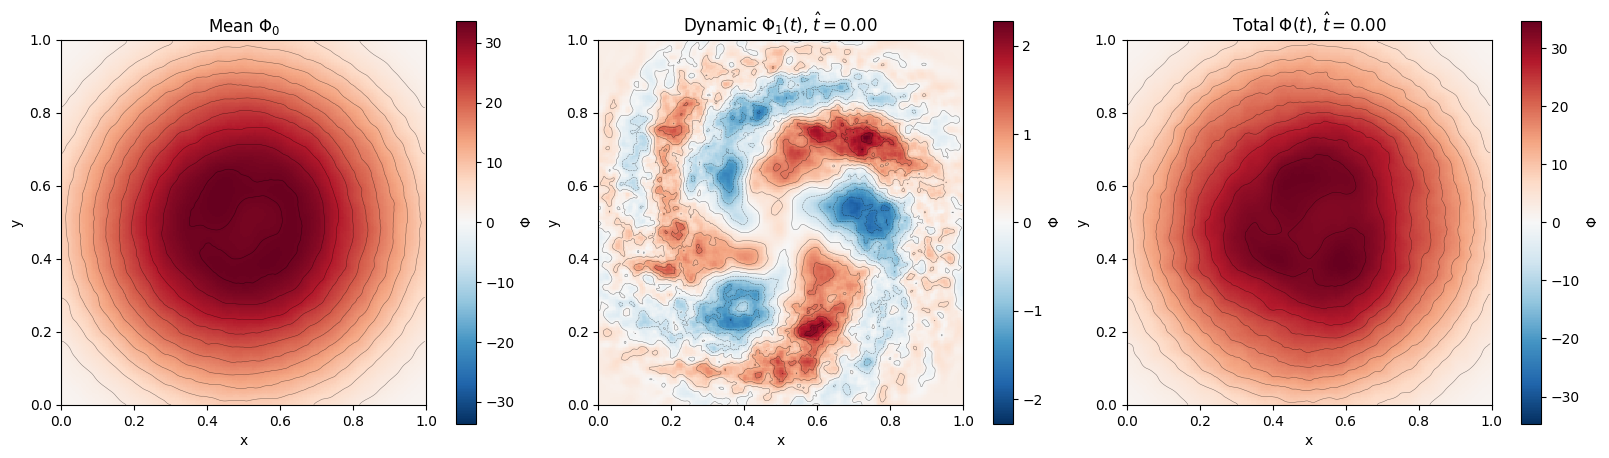

In [3]:
mean_field = np.asarray(potential.mean, dtype=float)
total_field = potential.evaluate_grid(snapshot_time)
dynamic_field = total_field - mean_field

panels = (
    (mean_field, r"Mean $\Phi_0$"),
    (dynamic_field, rf"Dynamic $\Phi_1(t)$, $\hat t={snapshot_time:.2f}$"),
    (total_field, rf"Total $\Phi(t)$, $\hat t={snapshot_time:.2f}$"),
)
figure, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)
for axis, (field, title) in zip(axes, panels):
    bound = float(np.max(np.abs(field)))
    if np.isclose(bound, 0.0):
        bound = 1.0
    mesh = axis.pcolormesh(
        potential.grid.x,
        potential.grid.y,
        field.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=-bound,
        vmax=bound,
    )
    axis.contour(
        potential.grid.x,
        potential.grid.y,
        field.T,
        levels=12,
        colors="black",
        linewidths=0.35,
        alpha=0.5,
    )
    figure.colorbar(mesh, ax=axis, label=r"$\Phi$")
    axis.set(
        xlabel="x",
        ylabel="y",
        title=title,
        aspect="equal",
        xlim=(potential.grid.x0, potential.grid.x0 + potential.grid.period),
        ylim=(potential.grid.y0, potential.grid.y0 + potential.grid.period),
    )
plt.show()

## Total potential and electric field

The arrows show $\mathbf{E}=-\nabla\Phi$. They are sampled on a coarser grid only to keep the plot legible.

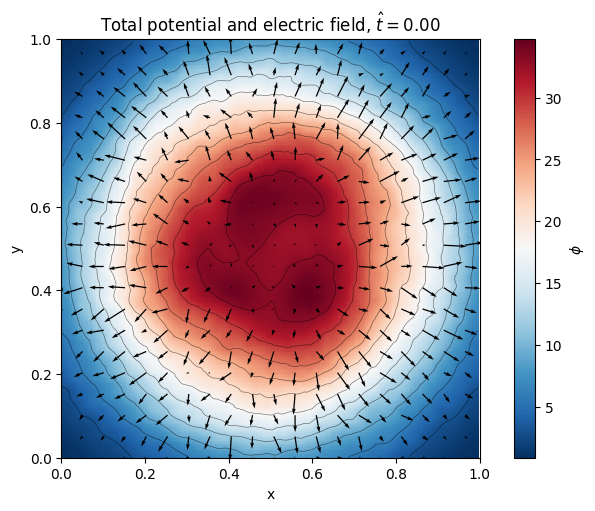

In [4]:
figure, axis = plot_potential(potential, t=snapshot_time, show=False)
stride = max(1, int(np.ceil(max(potential.grid.shape) / 20)))
quiver_x, quiver_y = np.meshgrid(
    potential.grid.x[::stride],
    potential.grid.y[::stride],
    indexing="ij",
)
electric_x, electric_y = potential.electric_field(
    snapshot_time, quiver_x, quiver_y
)
axis.quiver(
    quiver_x,
    quiver_y,
    electric_x,
    electric_y,
    color="black",
    width=0.003,
)
axis.set_title(rf"Total potential and electric field, $\hat t={snapshot_time:.2f}$")
plt.show()

## Temporal evolution at the center of the sampled domain

The signal is shown at the default saved-step cadence from normalized time $\hat t=0$ through $\hat t=10$. The 101 samples include the initial state and both endpoints, allowing closure to be verified after ten complete cycles.

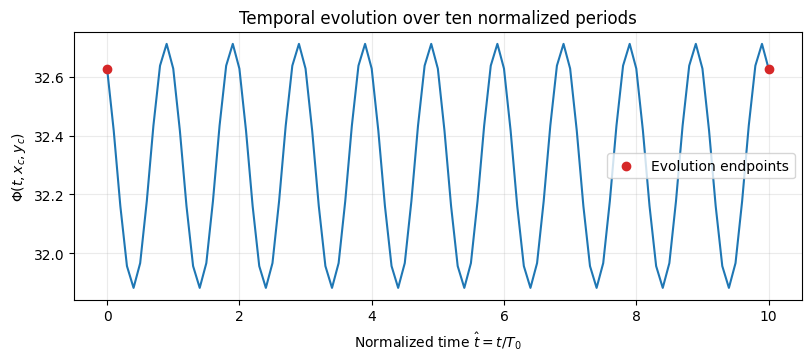

Ten-cycle closure error: 0.000e+00


In [5]:
center_x = float(potential.grid.x0 + 0.5 * potential.grid.period)
center_y = float(potential.grid.y0 + 0.5 * potential.grid.period)
saved_times = np.linspace(0.0, FINAL_TIME, SAVED_SAMPLE_COUNT)
center_trace = potential.evaluate(saved_times, center_x, center_y)

figure, axis = plt.subplots(figsize=(8, 3.5), constrained_layout=True)
axis.plot(saved_times, center_trace, color="tab:blue", linewidth=1.5)
axis.scatter(
    [0.0, FINAL_TIME],
    [center_trace[0], center_trace[-1]],
    color="tab:red",
    zorder=3,
    label="Evolution endpoints",
)
axis.set(
    xlabel=r"Normalized time $\hat t=t/T_0$",
    ylabel=r"$\Phi(t,x_c,y_c)$",
    title="Temporal evolution over ten normalized periods",
)
axis.grid(alpha=0.25)
axis.legend()
plt.show()

print(f"Ten-cycle closure error: {abs(center_trace[-1] - center_trace[0]):.3e}")

## Animation through normalized time 10

The animation uses 100 frames on the saved-time grid in $[0,10)$: 10 frames for each normalized cycle, played at 5 frames per second. Each normalized cycle therefore occupies two seconds of playback. The final endpoint is stored for diagnostics but omitted from the animation because it closes the periodic field and would duplicate the first frame.

In [6]:
animation = animate_potential(
    potential,
    t_max=FINAL_TIME,
    frames=ANIMATION_FRAMES,
    interval=ANIMATION_INTERVAL_MS,
    repeat=True,
)
display_animation(animation)

## Interpretation

- With the supplied file and default selection, the potential repeats after one normalized temporal period $\hat T=1$; consequently, an evolution ending at $\hat t=10$ contains exactly ten cycles.
- The default temporal discretization uses $\Delta \hat t=1/10$ for integration and saves every integration step, giving $\Delta \hat t_{\mathrm{save}}=1/10$.
- Animation uses every non-duplicated saved time at 5 fps, so each normalized cycle occupies two seconds of playback.
- `spatial_normalization="unit_box"` maps the complete periodic source box to $[0,1) \times [0,1)$, so `potential.grid.period` is exactly $1$ for both axes.
- HDF5 runtime interpolation wraps positions periodically over that complete box.
- Particle trajectories in this time-periodic field are not required to be periodic.